Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ASK120305
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/zalando-research/fashionmnist


100%|██████████| 68.8M/68.8M [00:00<00:00, 150MB/s]



Training samples: 60000
Image shape: (28, 28, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 75s 97ms/step - accuracy: 0.8247 - loss: 0.4902 - val_accuracy: 0.8764 - val_loss: 0.3458
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 65s 86ms/step - accuracy: 0.8853 - loss: 0.3190 - val_accuracy: 0.9001 - val_loss: 0.2773
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 87ms/step - accuracy: 0.8993 - loss: 0.2736 - val_accuracy: 0.9034 - val_loss: 0.2678
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 64s 85ms/step - accuracy: 0.9118 - loss: 0.2396 - val_accuracy: 0.9122 - val_loss: 0.2456
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 68s 91ms/step - accuracy: 0.9210 - loss: 0.2133 - val_accuracy: 0.9174 - val_loss: 0.2386
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 63s 84ms/step - accuracy: 0.9288 - loss: 0.1928 - val_accuracy: 0.9177 - val_loss: 0.2351
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 84ms/step - accuracy: 0.9354 - loss: 0.1732 - val_accuracy: 0.9196 - val_loss: 0.2323
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 61s 81ms/step - accuracy: 0.9411 - loss: 0.1568 - 

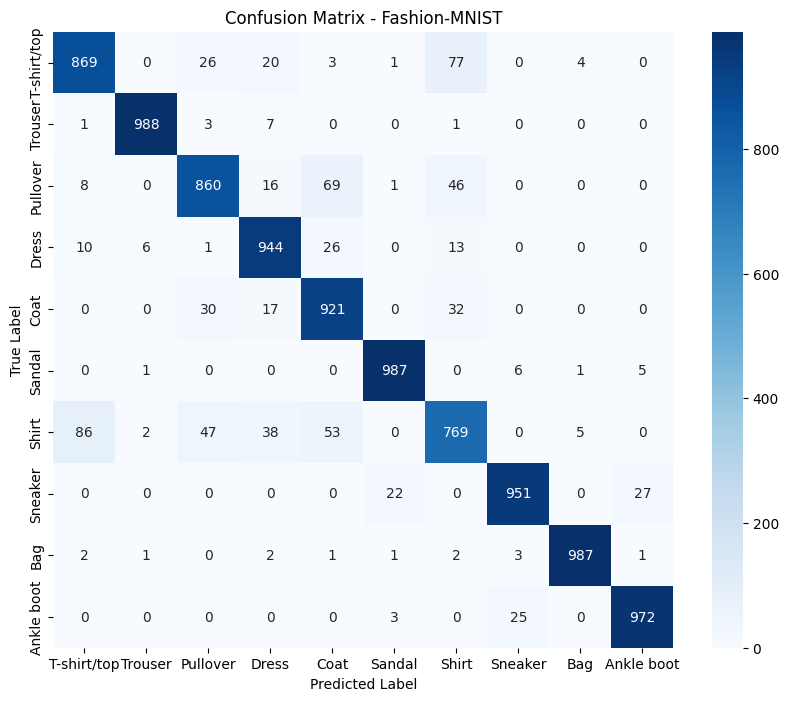

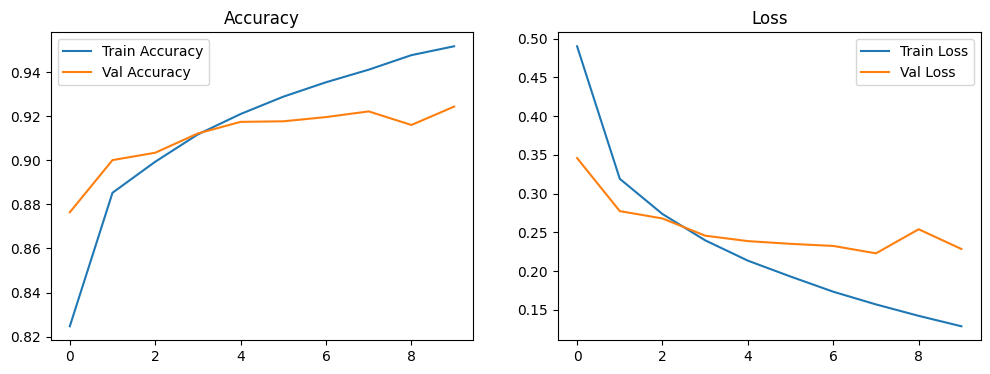

In [4]:
# Install the required library for Kaggle imports
!pip install opendatasets

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import opendatasets as od
import os
import pandas as pd

# --- 1. LOAD DATA DIRECTLY FROM KAGGLE ---
# Note: You will be prompted for your Kaggle Username and API Key
print("Downloading Fashion-MNIST dataset from Kaggle...")
dataset_url = "https://www.kaggle.com/datasets/zalando-research/fashionmnist"
od.download(dataset_url)

# Path to the downloaded CSV files
data_dir = "./fashionmnist"
train_df = pd.read_csv(os.path.join(data_dir, "fashion-mnist_train.csv"))
test_df = pd.read_csv(os.path.join(data_dir, "fashion-mnist_test.csv"))

# Convert CSV data to Numpy arrays and reshape to (28, 28, 1) for CNN
X_train = train_df.iloc[:, 1:].values.reshape(-1, 28, 28, 1)
y_train = train_df.iloc[:, 0].values
X_test = test_df.iloc[:, 1:].values.reshape(-1, 28, 28, 1)
y_test = test_df.iloc[:, 0].values

# Fashion-MNIST classes
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# --- 2. PREPROCESS ---
# Normalize pixel values to be between 0 and 1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# y labels are already 1D arrays from the CSV
print(f"Training samples: {X_train.shape[0]}")
print(f"Image shape: {X_train.shape[1:]}") # Should be (28, 28, 1)

# --- 3. BUILD CNN ---
# Keeping the structure identical to your original code
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)), # Updated input shape for 28x28 grayscale
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# --- 4. TRAIN ---
# Training for 10 epochs
history = model.fit(X_train, y_train, epochs=10,
                    batch_size=64, validation_split=0.2)

# --- 5. EVALUATE ---
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

# Predictions for Confusion Matrix
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# --- 6. VISUALIZE ---
# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Fashion-MNIST')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Training Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()